# Logistic Regression

# 1. Imports

In [11]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os, json
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    precision_recall_curve, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 2. Config

In [ ]:
import datetime, json as _json, time

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_NAME = "Logistic Regression"
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR  = os.path.join("model_outputs", f"{TIMESTAMP}_{RUN_NAME.replace(' ', '_')}")
DATA_DIR = 'preprocessed'
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"All outputs will be saved to: {RUN_DIR}/")

Device: cuda
All outputs will be saved to: runs\Logistic Regression/


# 3. Load Preprocessed Data and Metadata

In [ ]:
print("\nLoading preprocessed data...")
train = pd.read_csv(f'{DATA_DIR}/train.csv')
val   = pd.read_csv(f'{DATA_DIR}/val.csv')
test  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

target      = metadata['target']
feature_cols = [c for c in train.columns if c != target]

X_train = train[feature_cols].values.astype(np.float32)
y_train = train[target].values.astype(np.float32)
X_val   = val[feature_cols].values.astype(np.float32)
y_val   = val[target].values.astype(np.float32)
X_test  = test[feature_cols].values.astype(np.float32)
y_test  = test[target].values.astype(np.float32)

batch_size   = 1024
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(seed)
)
val_loader  = DataLoader(
    TensorDataset(torch.from_numpy(X_val),  torch.from_numpy(y_val)),
    batch_size=batch_size, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=batch_size, shuffle=False
)


Loading preprocessed data...


# 4. Model Archtiecture

In [14]:
class LogisticModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)   # raw logits

fraud_ratio = y_train.mean()
pos_weight  = torch.tensor(1.0 / fraud_ratio, device=DEVICE)
criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

model     = LogisticModel(X_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 5. Training

In [15]:
@torch.no_grad()
def evaluate_pr(loader):
    model.eval()
    all_prob, all_y = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        prob = torch.sigmoid(model(xb)).cpu().numpy()
        all_prob.extend(prob)
        all_y.extend(yb.numpy())
    return average_precision_score(np.array(all_y), np.array(all_prob))

@torch.no_grad()
def get_predictions(loader):
    model.eval()
    all_prob, all_y = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        prob = torch.sigmoid(model(xb)).cpu().numpy()
        all_prob.extend(prob)
        all_y.extend(yb.numpy())
    return np.array(all_y), np.array(all_prob)

epochs          = 40
history         = {'train_loss': [], 'val_pr': []}
best_val_pr     = 0
best_state      = None
epoch_log_rows  = []

print(f"\nTraining Logistic Regression for {epochs} epochs...")
print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}")
print(f"  {'-'*6}  {'-'*8}  {'-'*10}")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)

    train_loss = total_loss / len(train_loader.dataset)
    val_pr     = evaluate_pr(val_loader)

    history['train_loss'].append(train_loss)
    history['val_pr'].append(val_pr)

    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {epoch:>6}/{epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}")
    epoch_log_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_pr': val_pr})

pd.DataFrame(epoch_log_rows).to_csv(os.path.join(RUN_DIR, 'training_log.csv'), index=False)


Training Logistic Regression for 40 epochs...
   Epoch      Loss  Val PR-AUC
  ------  --------  ----------
       1/40   23.0766      0.2789
       2/40    1.0175      0.3141
       3/40    1.0399      0.3294
       4/40    1.0482      0.3428
       5/40    1.0186      0.3531
       6/40    0.9921      0.3165
       7/40    1.0148      0.3615
       8/40    1.0010      0.3344
       9/40    1.0310      0.3524
      10/40    0.9796      0.3569
      11/40    1.0040      0.3525
      12/40    0.9912      0.3591
      13/40    1.0177      0.3602
      14/40    0.9944      0.3512
      15/40    1.0004      0.3616
      16/40    1.0059      0.3277
      17/40    1.0107      0.3632
      18/40    1.0112      0.3597
      19/40    0.9958      0.3597
      20/40    1.0519      0.3476
      21/40    0.9787      0.3661
      22/40    0.9950      0.3430
      23/40    1.0093      0.3500
      24/40    0.9789      0.3659
      25/40    0.9977      0.3596
      26/40    1.0271      0.3523
      2

# 6. Evaluation

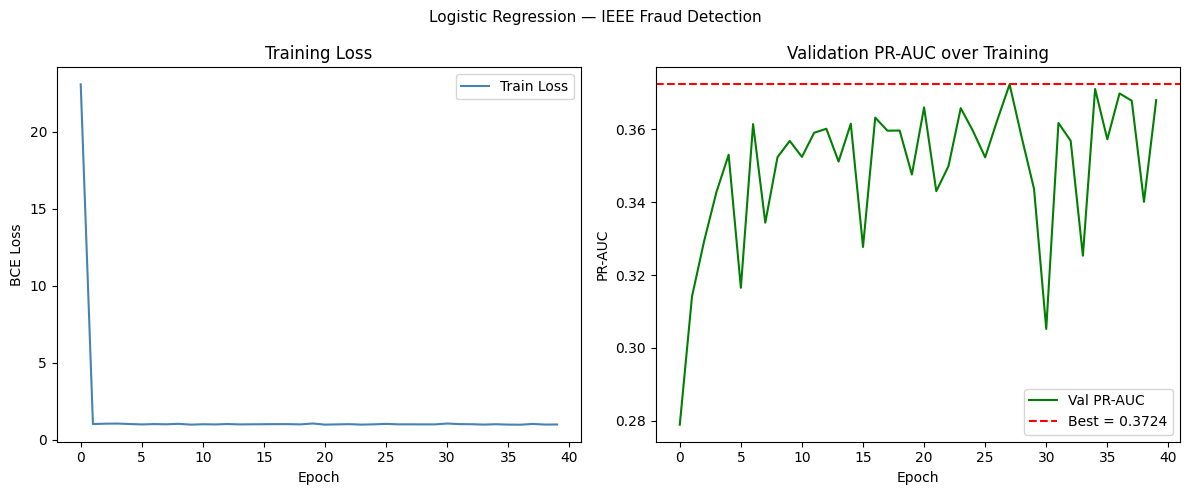

Training curves saved to runs\Logistic Regression\logreg_training_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history['train_loss'], color='steelblue', label='Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(history['val_pr'], color='green', label='Val PR-AUC')
axes[1].axhline(y=best_val_pr, color='red', linestyle='--',
                label=f'Best = {best_val_pr:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Validation PR-AUC over Training'); axes[1].legend()

plt.suptitle('Logistic Regression — IEEE Fraud Detection', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'logreg_training_curves.png')
plt.savefig(curves_path, dpi=150); plt.show()
print(f"Training curves saved to {curves_path}")

In [17]:
model.load_state_dict(best_state)

val_pr  = evaluate_pr(val_loader)
test_pr = evaluate_pr(test_loader)
print(f"\n{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Val  PR-AUC : 0.3724
  Test PR-AUC : 0.3654


# 7. Plots

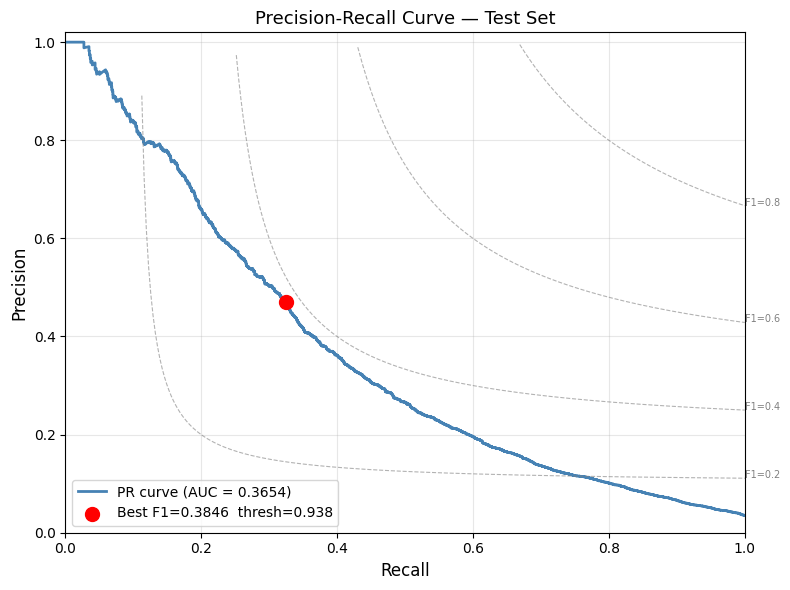

PR curve saved to runs\Logistic Regression\pr_curve.png


In [18]:
y_true, y_prob = get_predictions(test_loader)
precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_prob)

f1_scores   = (2 * precision_pts[:-1] * recall_pts[:-1]
               / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])
best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')
for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_path, dpi=150); plt.show()
print(f"PR curve saved to {pr_path}")

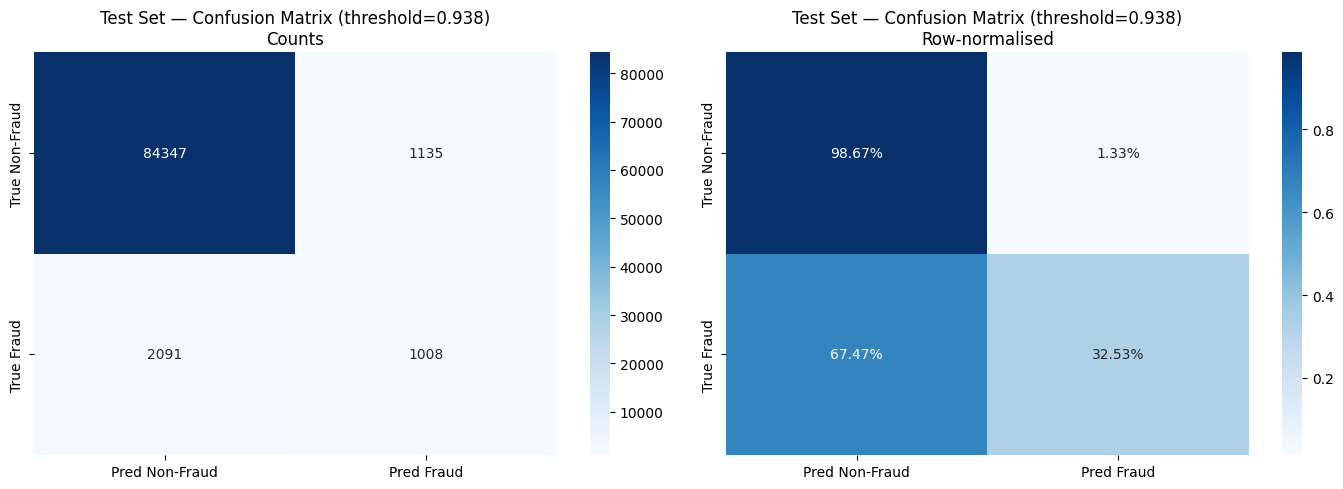


Classification Report (threshold=0.938):
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.99      0.98     85482
       Fraud       0.47      0.33      0.38      3099

    accuracy                           0.96     88581
   macro avg       0.72      0.66      0.68     88581
weighted avg       0.96      0.96      0.96     88581

Confusion matrix saved to runs\Logistic Regression\confusion_matrix.png


In [19]:
def plot_confusion_matrix(y_true, y_prob, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150); plt.show()

    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(f"\nClassification Report (threshold={threshold:.3f}):\n{report}")
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")
    print(f"Confusion matrix saved to {cm_path}")

plot_confusion_matrix(y_true, y_prob, threshold=best_thresh,
                      title="Test Set", save_dir=RUN_DIR)

### Validation recall at best threshold

In [22]:
val_y_true, val_proba = get_predictions(val_loader)
val_recall = recall_score(val_y_true,
                          (val_proba >= best_thresh).astype(int),
                          zero_division=0)

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC   : {test_pr:.4f}")
print(f"  Test F1       : {best_f1:.4f}")
print(f"  Test Recall   : {best_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall   : {val_recall:.4f}")


  Final Results at best threshold = 0.938
  Test PR-AUC   : 0.3654
  Test F1       : 0.3846
  Test Recall   : 0.3253
  Test Precision: 0.4704
  Val  Recall   : 0.3156


# 8. Save Model

In [23]:
final_metrics = {
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : best_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")

# ── Save model ────────────────────────────────────────────────────────────────
model_path = os.path.join(RUN_DIR, 'logreg_model.pt')
torch.save({
    'model_state_dict' : best_state,
    'feature_cols'     : feature_cols,
    'val_pr_auc'       : val_pr,
    'test_pr_auc'      : test_pr,
    'best_thresh'      : best_thresh,
    'test_recall'      : best_recall,
    'val_recall'       : val_recall,
}, model_path)

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    logreg_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    final_metrics.json")
print(f"    logreg_model.pt")
print(f"{'='*50}")


Final metrics saved to runs\Logistic Regression\final_metrics.json

  All outputs saved to: runs\Logistic Regression/
    logreg_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    final_metrics.json
    logreg_model.pt
